<a href="https://colab.research.google.com/github/Lateephah/spam_detection/blob/main/spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORT RELEVANT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import string
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# DATA LOADING

In this step, the dataset is loaded from Google Drive into a pandas DataFrame.  
The dataset contains SMS messages labeled as either **spam** or **ham (not spam)**.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/email_spam_detection/spam.csv', encoding='latin1')

#DATA CLEANING & PRE-PROCESSING

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [ ]:
df['Unnamed: 2'].value_counts()

,count
Unnamed: 2,
"bt not his girlfrnd... G o o d n i g h t . . .@""",3
"this wont even start........ Datz confidence..""",2
PO Box 5249,2
"don't miss ur best life for anything... Gud nyt...""",2
GN,2
"but dont try to prove it..\"" .Gud noon....""",2
"HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE JEN XXX\""""",1
".;-):-D""",1
"wanted to say hi. HI!!!\"" Stop? Send STOP to 62468""",1


In [ ]:
df['Unnamed: 2'].value_counts().sum()

np.int64(50)

In [ ]:
df['Unnamed: 3'].value_counts()

,count
Unnamed: 3,
"MK17 92H. 450Ppw 16""",2
GE,2
why to miss them,1
"U NO THECD ISV.IMPORTANT TOME 4 2MORO\""""",1
i wil tolerat.bcs ur my someone..... But,1
"ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\""""",1
"whoever is the KING\""!... Gud nyt""",1
TX 4 FONIN HON,1
"\""OH No! COMPETITION\"". Who knew",1


In [ ]:
df['Unnamed: 4'].value_counts()

,count
Unnamed: 4,
"GNT:-)""",2
"just Keep-in-touch\"" gdeve..""",1
"Never comfort me with a lie\"" gud ni8 and sweet dreams""",1
"CALL 2MWEN IM BK FRMCLOUD 9! J X\""""",1
"one day these two will become FREINDS FOREVER!""",1


In [ ]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.columns = ['label', 'message']

In [ ]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

The dataset initially contains extra columns (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) with mostly missing values.  
These columns are removed to retain only relevant information.

The columns are then renamed to:
- `label`: Indicates whether a message is spam or not
- `message`: The actual text content

Finally, the labels are converted into numeric format:
- `0` → Ham (Not Spam)
- `1` → Spam

In [ ]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


In [ ]:
df.isnull().sum()

,0
label,0
message,0


#Exploratory Data Analysis (EDA)

#Class Distribution

In [ ]:
df['label'].value_counts()

,count
label,
0,4825
1,747


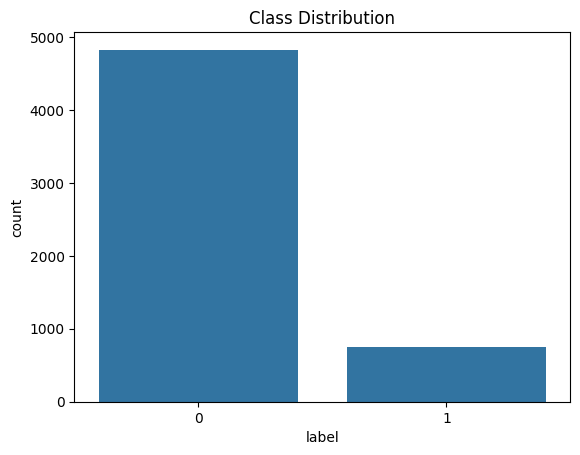

In [ ]:
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()

This visualization shows the distribution of spam vs non-spam messages.

We observe that:
- The dataset is **imbalanced**, with significantly more `ham` messages (4825) than `spam` (747).
- This imbalance may affect model performance, especially in detecting `spam` messages.

In [ ]:
df['length'] = df['message'].apply(len)

In [ ]:
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
df.groupby('label')['length'].mean()

,length
label,
0,71.023627
1,138.866131


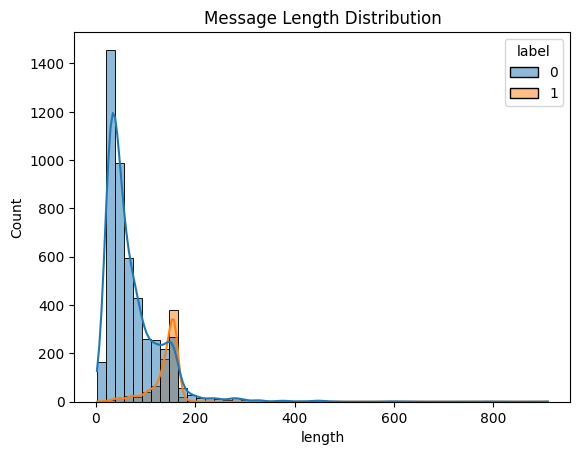

In [ ]:
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution')
plt.show()

We analyze the length of messages to understand differences between spam and ham messages.

Insights:
- Spam messages has the `average message length` of `138.89` which tend to be **longer and more structured**
- Ham messages has the `average message length` of `71.02`, typically **shorter and conversational**

This feature may help the model distinguish between the two classes.

#Text Preprocessing

In [ ]:
all_words = " ".join(df[df['label']==1]['message']).split()
Counter(all_words).most_common(10)

[('to', 604),
 ('a', 358),
 ('your', 187),
 ('call', 185),
 ('or', 185),
 ('the', 178),
 ('2', 169),
 ('for', 169),
 ('you', 164),
 ('is', 143)]

This is to get a general overview of the most common words in spam messages before any pre-processings like removal of punctuation, stopwords and word standardization (changing all text cases to lower case) are made

In [ ]:
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)

To prepare the text for machine learning:
- All text is converted to lowercase
- Punctuation is removed
- Stopwords (common words like "the", "is") are removed

This helps reduce noise and improves model performance.

In [ ]:
df['clean_message']

,clean_message
0,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni
2,free entry 2 wkly comp win fa cup final tkts 2...
3,u dun say early hor u c already say
4,nah dont think goes usf lives around though
...,...
5567,2nd time tried 2 contact u u å£750 pound prize...
5568,ì b going esplanade fr home
5569,pity mood soany suggestions
5570,guy bitching acted like id interested buying s...


In [ ]:
all_words = " ".join(df[df['label']==1]['clean_message']).split()
Counter(all_words).most_common(10)

[('call', 347),
 ('free', 216),
 ('2', 173),
 ('txt', 150),
 ('u', 147),
 ('ur', 144),
 ('mobile', 123),
 ('text', 120),
 ('4', 119),
 ('claim', 113)]

This is to get a general overview of the most common words in spam messages after all the neccessary pre-processings are made.

Key observations:
- Words like **"free", "call", "txt", "claim"** appear frequently
- These words are strong indicators of spam behavior

This confirms that spam messages follow recognizable patterns.

#Train-Test Split

In [ ]:
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

The dataset is split into training and testing sets:
- **Training set**: Used to train the models (80%)
- **Test set**: Used to evaluate performance (20%)

Stratified sampling is used to preserve the class distribution.

#Baseline Models

In this section, we train multiple machine learning models on the original dataset without handling class imbalance.

This serves as a baseline to evaluate whether imbalance handling techniques improve performance.

##Naive Bayes

In [ ]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

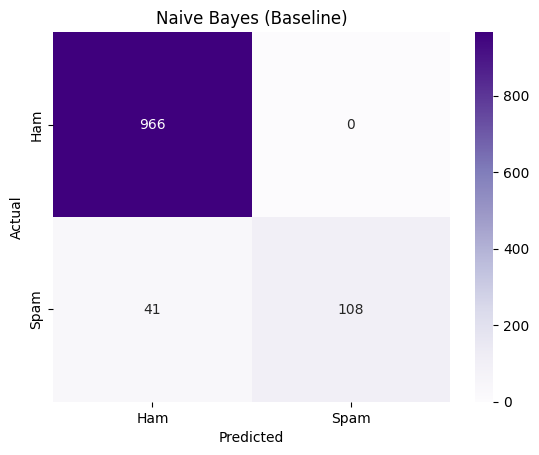

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes (Baseline)')
plt.show()

Intepretation:

- Top-left (966): True Negatives – These are correctly predicted Ham messages. Out of all the Ham texts, 966 were correctly classified as Ham.
- Top-right (0): False Positives – No Ham messages were incorrectly classified as Spam. This is excellent because false positives can frustrate users when legitimate emails get flagged.
- Bottom-left (41): False Negatives – These are Spam messages incorrectly predicted as Ham. This is the critical weakness here, since Spam slipping through is more harmful than Ham being blocked.
- Bottom-right (108): True Positives – Spam messages correctly identified as Spam.

Insight:
For spam detection, minimizing false negatives (Spam misclassified as Ham) is indeed crucial, because those are the unwanted messages that sneak into the inbox. However, keeping false positives low is also important to avoid losing legitimate communication.





In [ ]:
print(accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

0.9632286995515695
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



The Naive Bayes baseline model achieved 96% accuracy, but the class-level results reveal imbalance. For Ham (class 0), performance is nearly perfect with recall at 1.00 and F1-score at 0.98, showing the model strongly favors the majority class. For Spam (class 1), while precision is excellent (1.00), recall drops to 0.72, meaning almost a third of Spam messages were missed. This imbalance skews the macro averages (high precision, lower recall), confirming that without handling class imbalance, the model prioritizes Ham detection at the expense of Spam recall. Improving Spam recall is essential for a more reliable spam filter


##SVM

In [ ]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LinearSVC())
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

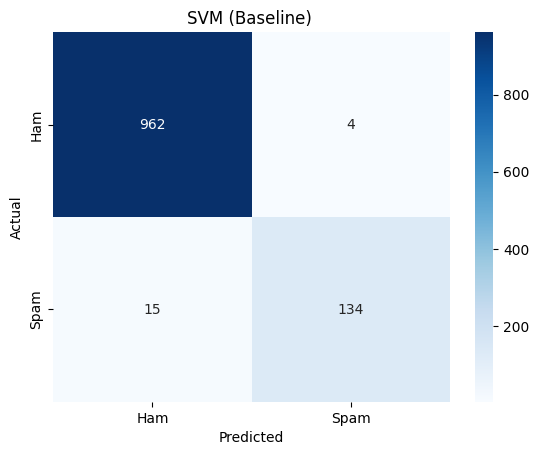

In [ ]:
cm2 = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted )
plt.ylabel('Actual')
plt.title('SVM (Baseline) ')
plt.show()

The SVM baseline model shows stronger balance compared to Naive Bayes. From the confusion matrix, most Ham messages were correctly classified (962), with only 4 misclassified as Spam. For Spam, 134 were correctly identified, while 15 slipped through as Ham.


In [ ]:
print(accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

0.9829596412556054
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.97      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



 The classification report confirms this: Ham (class 0) has near-perfect recall (1.00) and F1-score (0.99), while Spam (class 1) achieves high precision (0.97) and improved recall (0.90) compared to Naive Bayes. Overall accuracy is 98%, with macro averages showing solid performance across both classes. In short, the SVM baseline reduces false negatives significantly, making it more reliable for spam detection than the Naive Bayes baseline.


##Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', RandomForestClassifier())
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

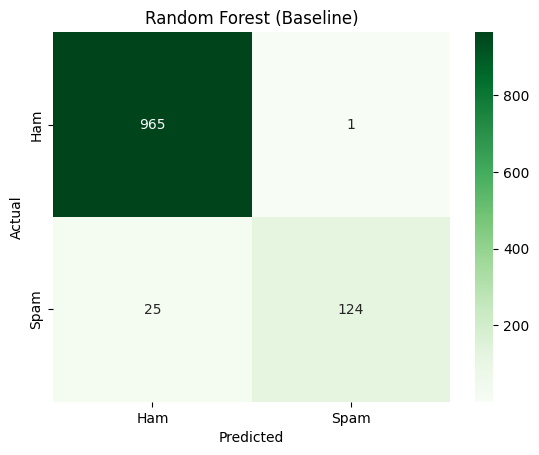

In [ ]:
cm3 = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest (Baseline)')
plt.show()

From the confusion matrix, 965 Ham messages were correctly classified, with only 1 misclassified as Spam. For Spam, 124 were correctly identified, while 25 were misclassified as Ham.


In [ ]:
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.9766816143497757
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.99      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



The Random Forest baseline model achieved 98% accuracy, performing very well overall but showing slightly weaker recall for Spam compared to SVM.
The classification report reflects the following: Ham (class 0) has near-perfect recall (1.00) and F1-score (0.99), while Spam (class 1) has excellent precision (0.99) but lower recall (0.83), leading to an F1-score of 0.91. In short, Random Forest maintains strong overall accuracy but still misses a notable portion of Spam, highlighting the need to improve recall for more effective spam filtering.


##Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

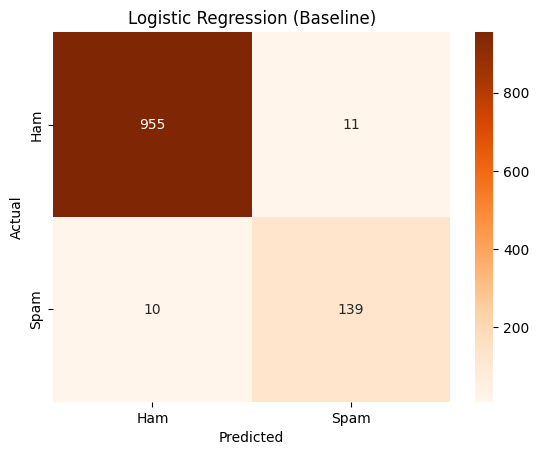

In [ ]:
cm4 = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm4, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression (Baseline)')
plt.show()

In [ ]:
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

0.9614349775784753
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.96      0.74      0.84       149

    accuracy                           0.96      1115
   macro avg       0.96      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



The Logistic Regression baseline model reached 96% accuracy, but its performance shows clear imbalance between Ham and Spam. From the confusion matrix, 955 Ham messages were correctly classified, with 11 misclassified as Spam. For Spam, 139 were correctly identified, while 10 were misclassified as Ham. The report highlights this: Ham (class 0) has near-perfect recall (1.00) and F1-score (0.98), while Spam (class 1) achieves good precision (0.96) but weaker recall (0.74), leading to a lower F1-score (0.84). Overall, Logistic Regression performs reliably on Ham but misses a notable portion of Spam, underscoring the need to improve recall for stronger spam detection.


#Oversampling Experiment

To address class imbalance, we apply **Random Oversampling** to the training data.

This technique duplicates minority class (spam) samples to balance the dataset.

Goal:
- Improve the model’s ability to detect spam

However, oversampling may lead to **overfitting** and reduced generalization.

#Feature Engineering (Vectorization)

In [ ]:
# Vectorize first
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

##Naive Bayes

In [ ]:
ros = RandomOverSampler()
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_vec, y_train)

model_os = MultinomialNB()
model_os.fit(X_train_resampled, y_train_resampled)

y_pred_os = model_os.predict(X_test_vec)

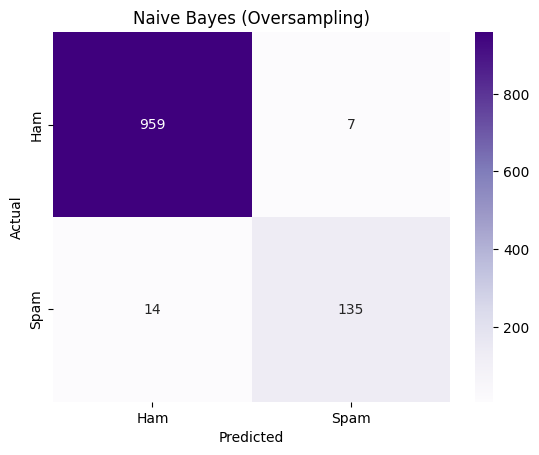

In [ ]:
cm5 = confusion_matrix(y_test, y_pred_os)

sns.heatmap(cm5, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes (Oversampling)')
plt.show()

With Random Oversampling applied, the Naive Bayes model improved its balance between Ham and Spam detection. From the confusion matrix, 959 Ham messages were correctly classified with only 7 misclassified as Spam, while 135 Spam messages were correctly identified and 14 misclassified as Ham.


In [ ]:
print(accuracy_score(y_test, y_pred_os))
print(classification_report(y_test, y_pred_os))

0.9704035874439462
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       966
           1       0.85      0.94      0.89       149

    accuracy                           0.97      1115
   macro avg       0.92      0.96      0.94      1115
weighted avg       0.97      0.97      0.97      1115



The classification report reflects this shift: Ham (class 0) maintains very high performance (precision 0.99, recall 0.98, F1-score 0.98), and Spam (class 1) shows a notable gain in recall (0.94) compared to the baseline, though precision drops slightly (0.85). Overall accuracy is 97%, with macro averages (precision 0.92, recall 0.96, F1-score 0.94) showing improved balance across both classes. In short, oversampling helped Naive Bayes catch more Spam messages, reducing false negatives, which makes the model more effective for spam detection.

##SVM

In [ ]:
model_os_svm = LinearSVC()
model_os_svm.fit(X_train_resampled, y_train_resampled)

y_pred_os_svm = model_os_svm.predict(X_test_vec)

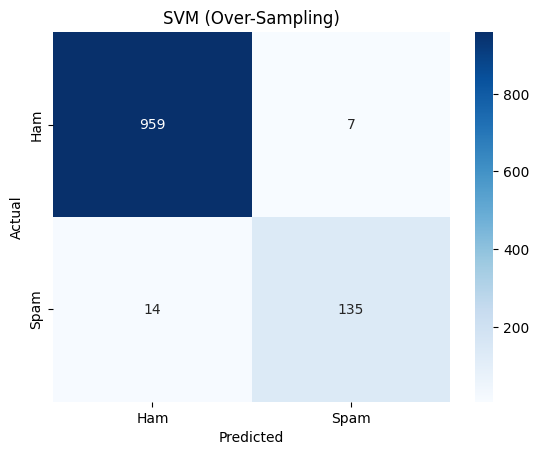

In [ ]:
cm6 = confusion_matrix(y_test, y_pred_os_svm)

sns.heatmap(cm6, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM (Over-Sampling)')
plt.show()

In [ ]:
print(accuracy_score(y_test, y_pred_os_svm))
print(classification_report(y_test,y_pred_os_svm))

0.9811659192825112
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.95      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



With Random Oversampling, the SVM model achieved 98% accuracy and delivered strong, balanced performance across both classes. From the confusion matrix, 959 Ham messages were correctly classified with 7 misclassified as Spam, while 135 Spam messages were correctly identified and 14 misclassified as Ham. The classification report shows Ham (class 0) with consistently high scores (precision 0.99, recall 0.99, F1-score 0.99), while Spam (class 1) also performs well with precision 0.95, recall 0.91, F1-score 0.93. Overall, oversampling helped the SVM reduce false negatives compared to its baseline, making it more reliable for spam detection while maintaining excellent precision.

##Random Forest

In [ ]:
model_os_rf = RandomForestClassifier()
model_os_rf.fit(X_train_resampled, y_train_resampled)

y_pred_os_rf = model_os_rf.predict(X_test_vec)

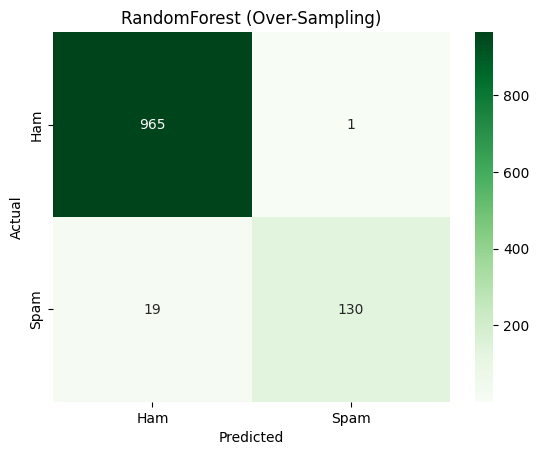

In [ ]:
cm7 = confusion_matrix(y_test, y_pred_os_rf)

sns.heatmap(cm7, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RandomForest (Over-Sampling)')
plt.show()

In [ ]:
print(accuracy_score(y_test, y_pred_os_rf))
print(classification_report(y_test,y_pred_os_rf))

0.9820627802690582
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



With Random Oversampling, the Random Forest baseline model reached 98% accuracy and maintained very strong performance on Ham while improving Spam detection compared to the non-oversampled version. From the confusion matrix, 965 Ham messages were correctly classified with only 1 misclassified as Spam, while 130 Spam messages were correctly identified and 19 misclassified as Ham. The classification report shows Ham (class 0) with near-perfect recall (1.00) and F1-score (0.99), while Spam (class 1) achieves excellent precision (0.99) and improved recall (0.87), leading to a solid F1-score (0.93). Overall, oversampling helped reduce false negatives for Spam, making Random Forest more balanced and reliable for spam detection.


##Logistic Regression

In [ ]:
model_os_lr = LogisticRegression(max_iter=1000)
model_os_lr.fit(X_train_resampled, y_train_resampled)

y_pred_os_lr = model_os_lr.predict(X_test_vec)

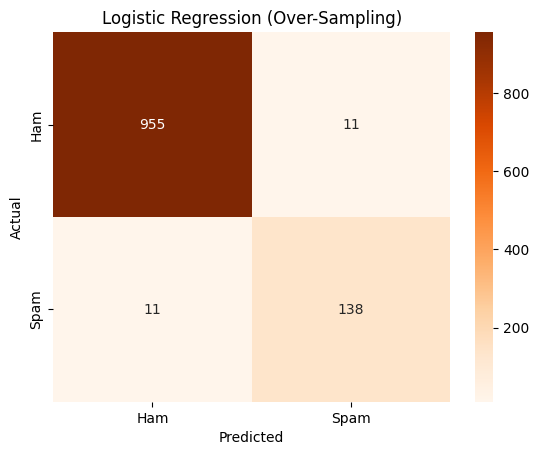

In [ ]:
cm8 = confusion_matrix(y_test, y_pred_os_lr)

sns.heatmap(cm8, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression (Over-Sampling)')
plt.show()

In [ ]:
print(accuracy_score(y_test, y_pred_os_lr))
print(classification_report(y_test,y_pred_os_lr))

0.9802690582959641
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.93      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



With Random Oversampling, the Logistic Regression model achieved 98% accuracy and showed much stronger balance between Ham and Spam detection compared to its baseline. From the confusion matrix, 955 Ham messages were correctly classified with 11 misclassified as Spam, while 138 Spam messages were correctly identified and 11 misclassified as Ham. The classification report confirms this: Ham (class 0) remains highly accurate (precision 0.99, recall 0.99, F1-score 0.99), while Spam (class 1) improved significantly, reaching precision 0.93, recall 0.93, F1-score 0.93. Overall, oversampling helped Logistic Regression reduce false negatives and achieve balanced performance across both classes, making it a more reliable spam filter.

#Class Weight Models

Instead of modifying the dataset, class weighting adjusts how the model penalizes errors.

- Misclassifying spam (minority class) is penalized more heavily
- Helps the model focus more on detecting spam

This approach avoids duplication of data and often generalizes better.

In [ ]:
lr_pipeline2 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_pipeline2.fit(X_train, y_train)
y_pred_lr_cw = lr_pipeline2.predict(X_test)

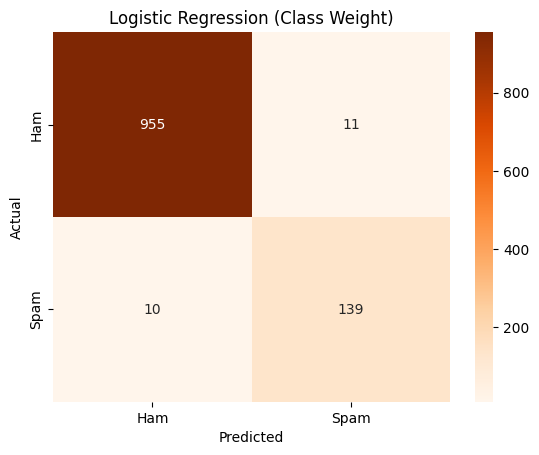

In [ ]:
cm9 = confusion_matrix(y_test, y_pred_lr_cw)

sns.heatmap(cm9, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression (Class Weight)')
plt.show()

In [ ]:
print(accuracy_score(y_test, y_pred_lr_cw))
print(classification_report(y_test,y_pred_lr_cw))

0.9811659192825112
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.93      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



Applying class weighting with Logistic Regression gave results very similar to oversampling, with overall 98% accuracy and balanced performance across both classes. From the confusion matrix, 955 Ham messages were correctly classified with 11 misclassified as Spam, while 139 Spam messages were correctly identified and 10 misclassified as Ham. The classification report shows Ham (class 0) remains highly accurate (precision 0.99, recall 0.99, F1-score 0.99), while Spam (class 1) also achieves strong scores (precision 0.93, recall 0.93, F1-score 0.93). In short, class weighting effectively addressed imbalance, reducing false negatives and producing a model that is both precise and reliable for spam detection.


#Comparative Analysis

In [ ]:
def evaluate_model(name, method, y_test, y_pred):
    return {
        'Model': name,
        'Method': method,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

In [ ]:
results = []

# Naive Bayes
results.append(evaluate_model('Naive Bayes', 'Baseline', y_test, y_pred_nb))
results.append(evaluate_model('Naive Bayes', 'Oversampling', y_test, y_pred_os))

# Logistic Regression
results.append(evaluate_model('Logistic Regression', 'Baseline', y_test, y_pred_lr))
results.append(evaluate_model('Logistic Regression', 'Oversampling', y_test, y_pred_os_lr))
results.append(evaluate_model('Logistic Regression', 'Class Weight', y_test, y_pred_lr_cw))

# SVM
results.append(evaluate_model('SVM', 'Baseline', y_test, y_pred_svm))
results.append(evaluate_model('SVM', 'Oversampling', y_test, y_pred_os_svm))

# Random Forest
results.append(evaluate_model('Random Forest', 'Baseline', y_test, y_pred_rf))
results.append(evaluate_model('Random Forest', 'Oversampling', y_test, y_pred_os_rf))

These tables below compares all models across different strategies:
- Baseline (no balancing)
- Oversampling
- Class weighting

Evaluation metrics:
- **Accuracy**: Overall correctness
- **Precision**: How many predicted spam messages are actually spam
- **Recall**: How many actual spam messages are detected
- **F1 Score**: Balance between precision and recall

This helps identify the best-performing model and strategy.

In [ ]:
results_df.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'], color='green')

,Model,Method,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,Baseline,0.963000,1.000000,0.725000,0.840000
1,Naive Bayes,Oversampling,0.981000,0.951000,0.906000,0.928000
2,Logistic Regression,Baseline,0.981000,0.927000,0.933000,0.930000
3,Logistic Regression,Oversampling,0.980000,0.926000,0.926000,0.926000
4,Logistic Regression,Class Weight,0.981000,0.927000,0.933000,0.930000
5,SVM,Baseline,0.983000,0.971000,0.899000,0.934000
6,SVM,Oversampling,0.981000,0.951000,0.906000,0.928000
7,Random Forest,Baseline,0.977000,0.992000,0.832000,0.905000
8,Random Forest,Oversampling,0.982000,0.992000,0.872000,0.929000


In [ ]:
results_df.style.highlight_min(subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'], color='maroon')

,Model,Method,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,Baseline,0.963000,1.000000,0.725000,0.840000
1,Naive Bayes,Oversampling,0.981000,0.951000,0.906000,0.928000
2,Logistic Regression,Baseline,0.981000,0.927000,0.933000,0.930000
3,Logistic Regression,Oversampling,0.980000,0.926000,0.926000,0.926000
4,Logistic Regression,Class Weight,0.981000,0.927000,0.933000,0.930000
5,SVM,Baseline,0.983000,0.971000,0.899000,0.934000
6,SVM,Oversampling,0.981000,0.951000,0.906000,0.928000
7,Random Forest,Baseline,0.977000,0.992000,0.832000,0.905000
8,Random Forest,Oversampling,0.982000,0.992000,0.872000,0.929000


Across all four models, the baseline results showed strong accuracy but clear imbalance, with Spam recall consistently weaker than Ham. After applying oversampling or class weighting, performance became more balanced, especially for Spam detection.
- Naive Bayes improved substantially with oversampling, raising Spam recall from 0.72 to 0.91, though precision dropped slightly.
- Logistic Regression performed consistently well, with both oversampling and class weighting yielding balanced metrics (precision ~0.93, recall ~0.93).
- SVM achieved the highest baseline accuracy (0.983) and maintained strong precision and recall after oversampling, showing reliable performance across classes.
- Random Forest had excellent precision (0.99) but weaker Spam recall in the baseline (0.83). Oversampling improved recall to 0.87, making it more balanced.
Overall, oversampling and class weighting helped reduce false negatives for Spam, leading to more dependable spam detection. SVM and Logistic Regression stood out as the most balanced models, while Random Forest and Naive Bayes benefited most from oversampling adjustments.
